In [47]:
# integration du notebook kaggle et aggregations avec les variables des autres fichiers

import os
import re
import numpy as np
import pandas as pd
import gc
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, auc
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold, cross_val_score, cross_val_predict,cross_validate
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import catboost
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, cv, Pool
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.catboost
import optuna
import shap


print(" Imports terminés")

 Imports terminés


In [3]:
print(catboost.__version__) # pour vérifier si __sklearn_tags__ s'implemente

1.2.10


In [4]:
# optimisation de la RAM
def reduce_mem_usage(df, verbose=True):
    """Réduit l'usage mémoire en convertissant les types de données"""
    start_mem = df.memory_usage().sum() / 1024**2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Mémoire réduite de {start_mem:.2f} MB à {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    
    return df

In [5]:
# bureau et bureau_balance
with open("bureau_agg.pkl", "rb") as f:
    bureau_agg = pickle.load(f)

gc.collect()

100

In [6]:
# Credit CARD 
with open("credit_card_client.pkl", "rb") as f:
    credit_card_client = pickle.load(f)

gc.collect()

0

In [7]:
# INSTALLMENTS
with open("installments_agg.pkl", "rb") as f: 
    installments_agg = pickle.load(f)

gc.collect()

0

In [8]:
# Previous Application 
with open('prev_agg.pkl', 'rb') as f:
    prev_agg = pickle.load(f)
    
gc.collect()

0

In [9]:
# POS_CASH 
with open('pos_agg.pkl', 'rb') as f:
    pos_agg = pickle.load(f)

gc.collect()

0

In [10]:
# application_train
with open("app_train_domain.pkl", "rb") as f:
    app_train_domain = pickle.load(f)

# application_test
with open("app_test_domain.pkl", "rb") as f:
    app_test_domain = pickle.load(f)

gc.collect()    

0

In [11]:
# Fusion progressive de toutes les tables sur SK_ID_CURR
print("Début de la fusion...")

# Partir de app_train_domain, variable du kernel kaggle
train = app_train_domain.copy()

print(f"Train initial: {train.shape}")

# Fusion avec Bureau
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')

print(f"Après bureau: {train.shape}")

# Fusion avec Credit Card 
train = train.merge(credit_card_client, on='SK_ID_CURR', how='left')

print(f"Après credit: {train.shape}")



# Fusion avec Installments:
## Cas particulier: Charger la correspondance SK_ID_PREV avec SK_ID_CURR de previous_application
## chargement des données depuis la racine du projet
data_dir = 'data/' 
prev_link = pd.read_csv(data_dir + 'previous_application.csv',
                        usecols=['SK_ID_CURR', 'SK_ID_PREV'])
prev_link = reduce_mem_usage(prev_link)

## Fusionner installments_agg avec la correspondance
installments_with_curr = prev_link.merge(
    installments_agg,
    on='SK_ID_PREV',
    how='left'
)
## Agréger au niveau client (SK_ID_CURR)
installments_agg = (installments_with_curr
                     .drop('SK_ID_PREV', axis=1)
                     .groupby('SK_ID_CURR')
                     .agg(['mean', 'max', 'min', 'sum']))

installments_agg.columns = ['INSTAL_' + '_'.join(col).upper()
                              for col in installments_agg.columns]
installments_agg.reset_index(inplace=True)

print(f"\n installments_agg shape: {installments_agg.shape}")

## Fusion avec train
train = train.merge(installments_agg, on='SK_ID_CURR', how='left')

print(f"Après installments: {train.shape}")



# Fusion avec Previous Application
train = train.merge(prev_agg, on='SK_ID_CURR', how='left')

print(f"Après previous: {train.shape}")

# Fusion avec POS_CASH
train = train.merge(pos_agg, on='SK_ID_CURR', how='left')

print(f"Après POS_CASH: {train.shape}")


print("\n Toutes les fusions terminées ")
print(f"\n Shape final TRAIN: {train.shape}")

Début de la fusion...
Train initial: (307511, 245)
Après bureau: (307511, 449)
Après credit: (307511, 558)
Mémoire réduite de 25.49 MB à 12.74 MB (50.0% reduction)

 installments_agg shape: (338857, 97)
Après installments: (307511, 654)
Après previous: (307511, 872)
Après POS_CASH: (307511, 894)

 Toutes les fusions terminées 

 Shape final TRAIN: (307511, 894)


In [12]:
# on vérifie à nouveau les Nan et les colonnes constantes sans intérêt pour alléger

# valeurs manquantes
missing_train = (train.isnull().sum() / len(train)).sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]

print(f"Colonnes avec valeurs manquantes: {len(missing_train)}")
print("\nTop 10 colonnes avec le plus de NaN:")
print(missing_train.head(10))

# Supprimer les colonnes avec > 75% de NaN
threshold = 0.75
cols_to_drop = missing_train[missing_train > threshold].index.tolist()
print(f"\nColonnes à supprimer (>{threshold*100}% NaN): {len(cols_to_drop)}")

if len(cols_to_drop) > 0:
    train = train.drop(columns=cols_to_drop)
    print(f" Après suppression des col avec NaN- Train: {train.shape}")


# suppression des colonnes constantes
constant_cols = [col for col in train.columns 
                 if train[col].nunique() <= 1]

train.drop(columns=constant_cols, inplace=True)

print(f" Après suppression des col avec bcp de NaN et constantes- Train: {train.shape}")

Colonnes avec valeurs manquantes: 714

Top 10 colonnes avec le plus de NaN:
INSTAL_INSTAL_COUNT_MEAN                1.000000
INSTAL_INSTAL_COUNT_MIN                 1.000000
INSTAL_INSTAL_COUNT_MAX                 1.000000
CC_CLIENT_CC_MONTHS_BALANCE_MAX_MAX     0.717392
CC_CLIENT_CC_MONTHS_BALANCE_MIN_MAX     0.717392
CC_CLIENT_CC_MONTHS_BALANCE_MAX_MEAN    0.717392
CC_CLIENT_CC_MONTHS_BALANCE_MIN_SUM     0.717392
CC_CLIENT_CC_MONTHS_BALANCE_MIN_MIN     0.717392
CC_CLIENT_CC_COUNT_RECORDS_MIN          0.717392
CC_CLIENT_CC_COUNT_RECORDS_MAX          0.717392
dtype: float64

Colonnes à supprimer (>75.0% NaN): 3
 Après suppression des col avec NaN- Train: (307511, 891)
 Après suppression des col avec bcp de NaN et constantes- Train: (307511, 875)


In [13]:
# Correlation entre features numériques
# Les modèles LightGBM, XGBoost, CatBoost gèrent très bien les redondances comme les corrélations

Top 15 features positivement corrélées avec TARGET:
TARGET                                             1.000000
CC_CLIENT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_SUM     0.118044
CC_CLIENT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_MEAN    0.118043
CC_CLIENT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_MAX     0.118015
CC_CLIENT_CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_MIN     0.117719
bureau_DAYS_CREDIT_MEAN                            0.089729
CC_CLIENT_CC_AMT_BALANCE_MEAN_SUM                  0.087657
CC_CLIENT_CC_AMT_BALANCE_MEAN_MAX                  0.087617
CC_CLIENT_CC_AMT_BALANCE_MEAN_MEAN                 0.087365
CC_CLIENT_CC_AMT_BALANCE_MEAN_MIN                  0.086997
PREV_NAME_CONTRACT_STATUS_REFUSED_MEAN             0.077671
CC_CLIENT_CC_AMT_DRAWINGS_ATM_CURRENT_MEAN_MEAN    0.077126
CC_CLIENT_CC_AMT_DRAWINGS_ATM_CURRENT_MEAN_MIN     0.077065
CC_CLIENT_CC_AMT_DRAWINGS_ATM_CURRENT_MEAN_SUM     0.076954
CC_CLIENT_CC_AMT_DRAWINGS_ATM_CURRENT_MEAN_MAX     0.076879
Name: TARGET, dtype: float64

Top 15 features né

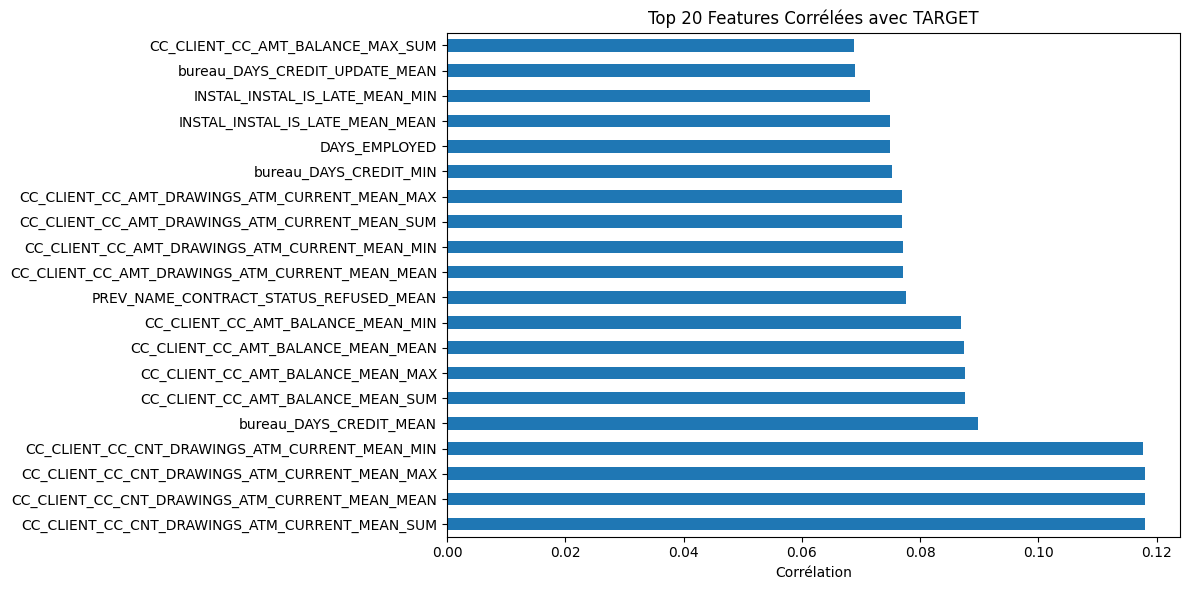

In [14]:
# Calculer les corrélations avec la TARGET
correlations = train.corr()['TARGET'].sort_values(ascending=False)

print("Top 15 features positivement corrélées avec TARGET:")
print(correlations.head(15))

print("\nTop 15 features négativement corrélées avec TARGET:")
print(correlations.tail(15))

print("\n Rappel: si présences de Nan: il faudra les traiter")

# Visualisation
plt.figure(figsize=(12, 6))
correlations.drop('TARGET').head(20).plot.barh()
plt.title('Top 20 Features Corrélées avec TARGET')
plt.xlabel('Corrélation')
plt.tight_layout()
plt.show()

In [42]:
# corrélation avec y:
# EXT_SOURCE_1,_2 et _3: corrélations négatives: plus la valeur est élevée, moins le client fait défaut
# idem pour CODE_GENDER_F
# DAYS_BIRTH: idem: plus le client est âgé, moins le client fait défaut
# corré positive: bureau_DAYS_CREDIT_MEAN: plus le credit est long, plus le client fait défaut

In [15]:
# vérification de y
y=train['TARGET']
print("\n1️ Vérification de y (TARGET):")
print(f"   Type: {y.dtype}")
print(f"   Valeurs uniques: {y.unique()}")
print(f"   Distribution: \n{y.value_counts()}")

# si y est déjà en 0/1, pas besoin d'encoder
if set(y.unique()) == {0, 1}:
    print("    y est déjà encodé en 0/1")
else:
    print("    y n'est pas en 0/1, encodage nécessaire")


1️ Vérification de y (TARGET):
   Type: int64
   Valeurs uniques: [1 0]
   Distribution: 
TARGET
0    282686
1     24825
Name: count, dtype: int64
    y est déjà encodé en 0/1


In [16]:
mapping_cible = {0: "rembourse le crédit", 1: "ne rembourse pas le crédit"}  # mapping cible pour s'assurer que  0 et 1 sont bien interprétés
y = y.map(mapping_cible)

In [ ]:
# Préparer et séparer features X et target y

# on garde les lignes de app_train_domain quand y(target) existe en 0 ou 1 pour éviter les NaN dans y
train_clean = app_train_domain.dropna(subset=['TARGET']).copy() 

# On enlève la colonne y (target) de X et l'ID qui n'est pas une feature pour le modèle
X = train_clean.drop(columns=['TARGET', 'SK_ID_CURR']).fillna(-999)
y = train_clean['TARGET'].astype(int)  # pour avoir 0 et 1 en nombre entier

# Test : utiliser app_test_domain
X_test = app_test_domain.drop(columns=['SK_ID_CURR'], errors='ignore').fillna(-999)

# Aligner les colonnes
X, X_test = X.align(X_test, join='inner', axis=1)

print(f"\n Préparation OK:")
print(f"   X:      {X.shape}")
print(f"   y:      {y.shape}  |  valeurs: {sorted(y.unique())}")
print(f"   X_test: {X_test.shape}")
print(f"   NaN dans y: {y.isnull().sum()}")
print(f"   Distribution y: {y.value_counts().to_dict()}")

# Split stratifié
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # stratification pour maintenir la même proportion de classes dans les splits
)

print(f"\n Split OK:")
print(f"   X_train: {X_train.shape}  |  défauts: {y_train.mean():.2%}")  # tx défaut paiement dans le train
print(f"   X_val:   {X_val.shape}    |  défauts: {y_val.mean():.2%}")
print(f"   X_test:  {X_test.shape}")


print("\n Données prêtes pour la modélisation")


 Préparation OK:
   X:      (307511, 239)
   y:      (307511,)  |  valeurs: [np.int64(0), np.int64(1)]
   X_test: (48744, 239)
   NaN dans y: 0
   Distribution y: {0: 282686, 1: 24825}

 Split OK:
   X_train: (246008, 239)  |  défauts: 8.07%
   X_val:   (61503, 239)    |  défauts: 8.07%
   X_test:  (48744, 239)

 Données prêtes pour la modélisation


In [18]:
# création de l'expérience mlflow
mlflow.set_experiment("Home_Credit_Default_Risk")


2026/02/20 20:35:24 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/20 20:35:24 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/20 20:35:24 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/20 20:35:24 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/20 20:35:24 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/20 20:35:24 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/20 20:35:26 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/20 20:35:26 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='file:c:/Users/chris/Initiez_vous_au_ML_Ops/mlruns/1', creation_time=1771437236622, experiment_id='1', last_update_time=1771437236622, lifecycle_stage='active', name='Home_Credit_Default_Risk', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [19]:
# Class weight (cas de déséquilibre de classe)

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nPoids calculés: {class_weight_dict}")
print(f"  La classe minoritaire (1) a un poids ~{class_weights[1]/class_weights[0]:.1f}x moins élevé")



Poids calculés: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}
  La classe minoritaire (1) a un poids ~11.4x moins élevé


In [20]:
# Tests des modèles

In [21]:
# Regression logistique avec class weight et StratifiedKFold
# Créer le StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


with mlflow.start_run(run_name="LogisticRegression_ClassWeight"):

    
    lr_weighted = LogisticRegression(
        max_iter=500, 
        random_state=42, 
        class_weight='balanced',  # Automatique
        solver='liblinear'
    )
    # Cross-validation avec StratifiedKFold explicite
    cv_scores_lr_weighted = cross_val_score(
        lr_weighted, 
        X, y,  
        cv=skf,  
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    lr_weighted.fit(X_train, y_train)
    y_val_pred_proba_lr_w = lr_weighted.predict_proba(X_val)[:, 1]
    y_val_pred_lr_w = lr_weighted.predict(X_val)

    auc_lr_w = cv_scores_lr_weighted.mean() # associé à la cross validation en KFold
    accuracy_lr_w = accuracy_score(y_val, y_val_pred_lr_w)
    precision_lr_w = precision_score(y_val, y_val_pred_lr_w)
    recall_lr_w = recall_score(y_val, y_val_pred_lr_w)

    # log des paramètres
    mlflow.log_param("max_iter", 500)
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "balanced")

    # log métrique
    mlflow.log_metric("auc_lr_weighted", auc_lr_w)
    mlflow.log_metric("accuracy_lr_weighted", accuracy_lr_w)
    mlflow.log_metric("precision_lr_weighted", precision_lr_w)
    mlflow.log_metric("recall_lr_weighted", recall_lr_w)

    # Log modèle
    mlflow.sklearn.log_model(lr_weighted, "model_lr_weighted")

    print(f"   ROC AUC: {auc_lr_w:.4f}")
    print(f"Accuracy_lr_weighted : {accuracy_lr_w:.4f}")
    print(f"Precision_lr_weighted: {precision_lr_w:.4f}")
    print(f"Recall_lr_weighted   : {recall_lr_w:.4f}")

2026/02/20 20:57:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ROC AUC: 0.6655
Accuracy_lr_weighted : 0.6206
Precision_lr_weighted: 0.1265
Recall_lr_weighted   : 0.6266


In [22]:
# Random Forest avec class_weight et StratiedKFold
with mlflow.start_run(run_name="RandomForest_ClassWeight"):
    
    rf_weighted = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight='balanced',  # Automatique
        n_jobs=-1,
        verbose=0
    )
    # Cross-validation avec StratifiedKFold explicite
    cv_scores_rf_weighted = cross_val_score(
        rf_weighted, 
        X, y,  
        cv=skf,  
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    rf_weighted.fit(X_train, y_train)
    y_val_pred_proba_rf_w = rf_weighted.predict_proba(X_val)[:, 1]
    y_val_pred_rf_w= rf_weighted.predict (X_val)
    auc_rf_w = cv_scores_rf_weighted.mean() # associé à la cross validation en KFold
    accuracy_rf_w = accuracy_score(y_val, y_val_pred_rf_w)
    precision_rf_w = precision_score(y_val, y_val_pred_rf_w)
    recall_rf_w = recall_score(y_val, y_val_pred_rf_w)

    # log des paramètres
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("class_weight", "balanced")
    
    # log métrique
    mlflow.log_metric("roc_auc_rf_weighted", auc_rf_w)
    mlflow.log_metric("accuracy_rf_weighted", accuracy_rf_w)
    mlflow.log_metric("precision_rf_weighted", precision_rf_w)
    mlflow.log_metric("recall_rf_weighted", recall_rf_w)

    # Log modèle
    mlflow.sklearn.log_model(rf_weighted, "model_rf_weighted")

    print(f" ROC_AUC_rf_weighted: {auc_rf_w:.4f}")
    print(f"Accuracy_rf_weighted : {accuracy_rf_w:.4f}")
    print(f"Precision_rf_weighted: {precision_rf_w:.4f}")
    print(f"Recall_rf_weighted  : {recall_rf_w:.4f}")



2026/02/20 20:58:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 ROC_AUC_rf_weighted: 0.7124
Accuracy_rf_weighted : 0.6646
Precision_rf_weighted: 0.1461
Recall_rf_weighted  : 0.6512


Top 20 features les plus importantes:
                                               feature  importance
32                                        EXT_SOURCE_3    0.197896
31                                        EXT_SOURCE_2    0.175702
30                                        EXT_SOURCE_1    0.074486
9                                           DAYS_BIRTH    0.057262
10                                       DAYS_EMPLOYED    0.043121
7                                      AMT_GOODS_PRICE    0.029500
124               NAME_EDUCATION_TYPE_Higher education    0.024361
107                                      CODE_GENDER_F    0.024137
122                           NAME_INCOME_TYPE_Working    0.022174
127  NAME_EDUCATION_TYPE_Secondary / secondary special    0.022029
80                              DAYS_LAST_PHONE_CHANGE    0.021294
108                                      CODE_GENDER_M    0.018904
22                         REGION_RATING_CLIENT_W_CITY    0.017075
40                      

<Figure size 1200x800 with 0 Axes>

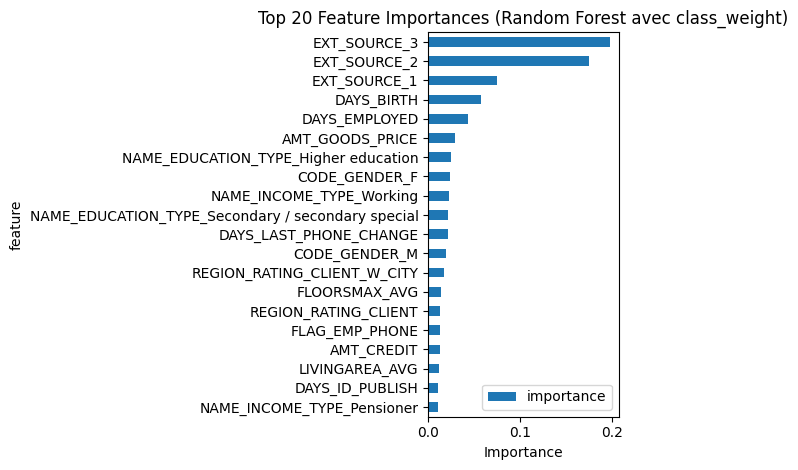

In [23]:
# Feature importances de Random Forest avec class_weight
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_weighted.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features les plus importantes:")
print(feature_importance.head(20))

# Visualisation
plt.figure(figsize=(12, 8))
feature_importance.head(20).plot.barh(x='feature', y='importance')
plt.title('Top 20 Feature Importances (Random Forest avec class_weight)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
# SMOTE équilibrer les classes en suréchantillonnant la classe minoritaire

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"   Avant SMOTE: {X_train.shape[0]} lignes")
print(f"   Après SMOTE: {X_train_smote.shape[0]} lignes")
print(f"\n   Distribution après SMOTE:")
print(f"     0: {(y_train_smote == 0).sum()} ({(y_train_smote == 0).mean()*100:.2f}%)")
print(f"     1: {(y_train_smote == 1).sum()} ({(y_train_smote == 1).mean()*100:.2f}%)")

   Avant SMOTE: 246008 lignes
   Après SMOTE: 452296 lignes

   Distribution après SMOTE:
     0: 226148 (50.00%)
     1: 226148 (50.00%)


In [25]:
# Logistic Regression sur données SMOTE et StratifiedKFold
with mlflow.start_run(run_name="LogisticRegression_SMOTE"):
    
    lr_smote = LogisticRegression(max_iter=500, random_state=42, solver='liblinear')
    # Cross-validation avec StratifiedKFold explicite
    cv_scores_lr_smote = cross_val_score(
        lr_smote, 
        X, y,  
        cv=skf,  
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    lr_smote.fit(X_train_smote, y_train_smote)
    y_val_pred_proba_lr_s = lr_smote.predict_proba(X_val)[:, 1]
    y_val_pred_lr_s= lr_smote.predict (X_val)
    auc_lr_s = cv_scores_lr_smote.mean() # associé à la cross validation en KFold
    accuracy_lr_s = accuracy_score(y_val, y_val_pred_lr_s)
    precision_lr_s = precision_score(y_val, y_val_pred_lr_s)
    recall_lr_s = recall_score(y_val, y_val_pred_lr_s)

    # log des paramètres
    mlflow.log_param("max_iter", 500)
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "smote")
    
    # log métrique
    mlflow.log_metric("roc_auc_lr_smote", auc_lr_s)
    mlflow.log_metric("accuracy_lr_smote", accuracy_lr_s)
    mlflow.log_metric("precision_lr_smote", precision_lr_s)
    mlflow.log_metric("recall_lr_smote", recall_lr_s)

    # Log modèle
    mlflow.sklearn.log_model(lr_smote, "model_lr_smote")

    print(f" ROC_AUC_lr_smote: {auc_lr_s:.4f}")
    print(f"Accuracy_lr_smote : {accuracy_lr_s:.4f}")
    print(f"Precision_lr_smote: {precision_lr_s:.4f}")
    print(f"Recall_lr_smote  : {recall_lr_s:.4f}")


2026/02/20 21:00:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 ROC_AUC_lr_smote: 0.6351
Accuracy_lr_smote : 0.6140
Precision_lr_smote: 0.1182
Recall_lr_smote  : 0.5857


In [26]:
# Random Forest sur données SMOTE et StratifiedKFold
with mlflow.start_run(run_name="RandomForest_SMOTE"):

    rf_smote = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbose=0)
    # Cross-validation avec StratifiedKFold explicite
    cv_scores_rf_smote = cross_val_score(
        rf_smote, 
        X, y,  
        cv=skf,  
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    rf_smote.fit(X_train_smote, y_train_smote)
    y_val_pred_proba_rf_s = rf_smote.predict_proba(X_val)[:, 1]
    y_val_pred_rf_s= rf_smote.predict (X_val)
    auc_rf_s = cv_scores_rf_smote.mean() # associé à la cross validation en KFold
    accuracy_rf_s = accuracy_score(y_val, y_val_pred_rf_s)
    precision_rf_s = precision_score(y_val, y_val_pred_rf_s)
    recall_rf_s = recall_score(y_val, y_val_pred_rf_s)

    # log des paramètres
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("class_weight", "smote")
    
    # log métrique
    mlflow.log_metric("roc_auc_rf_smote", auc_rf_s)
    mlflow.log_metric("accuracy_rf_smote", accuracy_rf_s)
    mlflow.log_metric("precision_rf_smote", precision_rf_s)
    mlflow.log_metric("recall_rf_smote", recall_rf_s)

    # Log modèle
    mlflow.sklearn.log_model(rf_smote, "model_rf_smote")

    print(f" ROC_AUC_rf_smote: {auc_rf_s:.4f}")
    print(f"Accuracy_rf_smote : {accuracy_rf_s:.4f}")
    print(f"Precision_rf_smote: {precision_rf_s:.4f}")
    print(f"Recall_rf_smote  : {recall_rf_s:.4f}")


2026/02/20 21:01:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 ROC_AUC_rf_smote: 0.7136
Accuracy_rf_smote : 0.8841
Precision_rf_smote: 0.1926
Recall_rf_smote  : 0.1364


Top 20 features les plus importantes:
                                               feature  importance
122                           NAME_INCOME_TYPE_Working    0.053154
32                                        EXT_SOURCE_3    0.045061
31                                        EXT_SOURCE_2    0.042350
127  NAME_EDUCATION_TYPE_Secondary / secondary special    0.042005
68                                      FLOORSMAX_MEDI    0.032078
108                                      CODE_GENDER_M    0.030001
13                                         OWN_CAR_AGE    0.026331
63                        YEARS_BEGINEXPLUATATION_MEDI    0.026327
40                                       FLOORSMAX_AVG    0.026241
54                                      FLOORSMAX_MODE    0.026043
30                                        EXT_SOURCE_1    0.025492
1                                         FLAG_OWN_CAR    0.022627
67                                      ENTRANCES_MEDI    0.022591
35                      

<Figure size 1200x800 with 0 Axes>

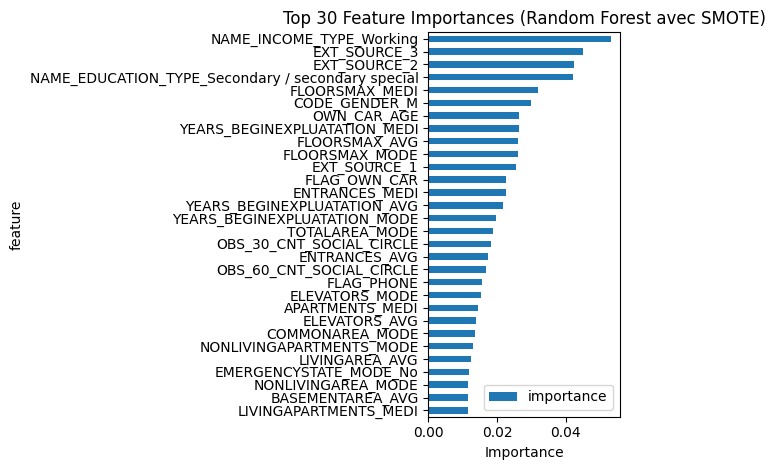

In [27]:
# Feature importances de Random Forest avec SMOTE
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_smote.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features les plus importantes:")
print(feature_importance.head(20))

# Visualisation
plt.figure(figsize=(12, 8))
feature_importance.head(30).plot.barh(x='feature', y='importance')
plt.title('Top 30 Feature Importances (Random Forest avec SMOTE)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
# Nettoyer les noms de colonnes: lightgbm ne supporte pas certains caracteres JSON (suite message erreur)

def clean_column_names(df):
    """Nettoie les noms de colonnes pour LightGBM"""
    new_columns = []
    for col in df.columns:
        # Remplacer les caractères spéciaux par des underscores
        col_clean = re.sub(r'[^A-Za-z0-9_]', '_', str(col))
        # Éviter les underscores multiples
        col_clean = re.sub(r'_+', '_', col_clean)
        # Enlever les underscores au début et à la fin
        col_clean = col_clean.strip('_')
        new_columns.append(col_clean)
    
    df.columns = new_columns
    return df

In [29]:
# application du nettoyage des colonnes
print(f"Avant: {X_train.columns[:5].tolist()} ...")

X_train = clean_column_names(X_train)
X_val = clean_column_names(X_val)
X_test = clean_column_names(X_test)

print(f"Après: {X_train.columns[:5].tolist()} ...")

# Vérifier qu'il n'y a plus de doublons
if X_train.columns.duplicated().any():
    print(" Attention: colonnes dupliquées détectées")
    # Ajouter un suffixe aux colonnes dupliquées
    X_train.columns = pd.io.common.dedup_names(X_train.columns, is_potential_multiindex=False)
    X_val.columns = X_train.columns
    X_test.columns = X_train.columns
    print(" Colonnes dupliquées renommées")

print(f"\n Nettoyage terminé")
print(f" Nombre de colonnes: {len(X_train.columns)}")

Avant: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL'] ...
Après: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL'] ...

 Nettoyage terminé
 Nombre de colonnes: 239


In [30]:
# LightGBM (format JSON) n’accepte pas certains caractères spéciaux dans les noms de features
# Nettoyage des colonnes à nouveau
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

[col for col in X.columns if not col.replace('_','').isalnum()]



[]

In [31]:
# LightGBM avec scale_pos_weight

# Calculer le ratio de déséquilibre
# Calcul du ratio sur tout y
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

with mlflow.start_run(run_name="LightGBM_Scale_Pos_Weight"):   

    model_lgb = LGBMClassifier(
        objective='binary',
        boosting_type='gbdt',
        learning_rate=0.05,
        max_depth=5,
        num_leaves=15,
        n_estimators=100,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    # Cross-validation StratifiedKFold
    cv_scores_lgb = cross_val_score(
        model_lgb,
        X,
        y,
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1
    )

    auc_lgb = cv_scores_lgb.mean()

    # Fit sur train
    model_lgb.fit(X_train, y_train)

    y_val_pred_proba_lgb = model_lgb.predict_proba(X_val)[:, 1]
    y_val_pred_lgb = model_lgb.predict(X_val)

    accuracy_lgb = accuracy_score(y_val, y_val_pred_lgb)
    precision_lgb = precision_score(y_val, y_val_pred_lgb)
    recall_lgb = recall_score(y_val, y_val_pred_lgb)

    # Logging MLflow
    mlflow.log_param("objective", "binary")
    mlflow.log_param("boosting_type", "gbdt")
    mlflow.log_param("num_leaves", 15)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)

    mlflow.log_metric("roc_auc_cv_mean", auc_lgb)
    mlflow.log_metric("accuracy_val", accuracy_lgb)
    mlflow.log_metric("precision_val", precision_lgb)
    mlflow.log_metric("recall_val", recall_lgb)

    mlflow.lightgbm.log_model(model_lgb, "model_lgb")

    print(f"ROC_AUC_lgb (CV mean): {auc_lgb:.4f}")
    print(f"Accuracy_lgb (val): {accuracy_lgb:.4f}")
    print(f"Precision_lgb (val): {precision_lgb:.4f}")
    print(f"Recall_lgb (val): {recall_lgb:.4f}")

    print("LightGBM terminé")



scale_pos_weight: 11.4
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.142769 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11517
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 230
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


2026/02/20 21:02:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/20 21:02:38 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.


ROC_AUC_lgb (CV mean): 0.7509
Accuracy_lgb (val): 0.6827
Precision_lgb (val): 0.1606
Recall_lgb (val): 0.6933
LightGBM terminé


In [32]:
# XGBoost avec scale_pos_weight

scale_pos_weight_xgb = (y_train == 0).sum() / (y_train == 1).sum()
print(f"   scale_pos_weight: {scale_pos_weight_xgb:.2f}")

with mlflow.start_run(run_name="XGBoost_Scale_Pos_Weight"):      
    xgb_params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'max_depth': 5,
            'learning_rate': 0.05,
            'scale_pos_weight': scale_pos_weight_xgb,  # Gère le déséquilibre
            'verbosity': 0
        }
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    model_xgb = XGBClassifier( 
        objective='binary:logistic', 
        eval_metric='auc', 
        max_depth=5, 
        learning_rate=0.05, 
        scale_pos_weight=scale_pos_weight_xgb, 
        n_estimators=100 
    )
    
    # Cross-validation avec StratifiedKFold explicite
    cv_scores_xgb = cross_val_score(
        model_xgb, 
        X, y,  
        cv=skf,  
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    auc_xgb = cv_scores_xgb.mean() # associé à la cross validation en KFold

    # refit sur train après la CV
    model_xgb.fit(X_train, y_train)

    y_val_pred_proba_xgb = model_xgb.predict_proba(X_val)[:, 1]
    y_val_pred_xgb = (y_val_pred_proba_xgb >= 0.5).astype(int)
    
    accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
    precision_xgb = precision_score(y_val, y_val_pred_xgb)
    recall_xgb = recall_score(y_val, y_val_pred_xgb)

    # tracking automatique en one shot directement dans mlflow (param, metrique, modele)
    mlflow.xgboost.autolog()

    print(f" ROC_AUC_xgb: {auc_xgb:.4f}")
    print(f"Accuracy_xgb : {accuracy_xgb:.4f}")
    print(f"Precision_xgb: {precision_xgb:.4f}")
    print(f"Recall_xgb  : {recall_xgb:.4f}")


   scale_pos_weight: 11.39
 ROC_AUC_xgb: 0.7503
Accuracy_xgb : 0.6882
Precision_xgb: 0.1620
Recall_xgb  : 0.6858


In [33]:
# CatBoost avec auto_class_weights

with mlflow.start_run(run_name="CatBoost_Auto_Class_Weights"):

    cat = CatBoostClassifier(
            iterations=100,
            depth=5,
            learning_rate=0.05,
            auto_class_weights='Balanced',  # Gère automatiquement
            eval_metric='AUC',
            random_seed=42,
            verbose=0
        )
    
     # CV native CatBoost
    train_pool = Pool(X, y)

    params = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'iterations': 100,
        'depth': 5,
        'learning_rate': 0.05,
        'verbose': False
    }

    cv_results = cv(
        params=params,
        pool=train_pool,
        fold_count=3,
        stratified=True,
        shuffle=True
    )

    auc_cat = cv_results['test-AUC-mean'].max()

    cat.fit(X_train, y_train)
    
    y_val_pred_proba_cat = cat.predict_proba(X_val)[:, 1]
    y_val_pred_cat = (y_val_pred_proba_cat >= 0.5).astype(int)
    
    accuracy_cat = accuracy_score(y_val, y_val_pred_cat)
    precision_cat = precision_score(y_val, y_val_pred_cat)
    recall_cat = recall_score(y_val, y_val_pred_cat)

    # tracking automatique en one shot directement dans mlflow (param, metrique, modele)
    # log métrique
    mlflow.log_metric("roc_auc_cat", auc_cat)
    mlflow.log_metric("accuracy_cat", accuracy_cat)
    mlflow.log_metric("precision_cat", precision_cat)
    mlflow.log_metric("recall_cat", recall_cat)

    # Log modèle
    mlflow.sklearn.log_model(cat, name="model_CatBoost_Auto_Class_Weights")

    print(f"   ROC AUC_cat: {auc_cat:.4f}")
    print(f"   Accuracy_cat: {accuracy_cat:.4f}")
    print(f"   Precision_cat: {precision_cat:.4f}")
    print(f"   Recall_cat: {recall_cat:.4f}")

Training on fold [0/3]

bestTest = 0.7461937116
bestIteration = 99

Training on fold [1/3]

bestTest = 0.7481853243
bestIteration = 99

Training on fold [2/3]

bestTest = 0.7402806204
bestIteration = 99

   ROC AUC_cat: 0.7449
   Accuracy_cat: 0.6804
   Precision_cat: 0.1586
   Recall_cat: 0.6874


In [34]:
# results summary

results = {
    'LR (class_weight)': auc_lr_w,
    'RF (class_weight)': auc_rf_w,
    'LR (SMOTE)': auc_lr_s,
    'RF (SMOTE)': auc_rf_s,
    'LightGBM (scale_pos_weight)': auc_lgb,
    'XGBoost (scale_pos_weight)': auc_xgb,
    'CatBoost (auto_class_weights)': auc_cat
}

print("\n ROC AUC sur validation set:")
for name, score in sorted(results.items(), key=lambda x: x[1] if x[1] else 0, reverse=True):
    if score is not None:
        print(f"   {name:30s}: {score:.4f}")

# best model, meilleur modèle
best = max([(n, s) for n, s in results.items() if s is not None], key=lambda x: x[1])
print(f"\n Meilleur modèle: {best[0]} (AUC = {best[1]:.4f})")


 ROC AUC sur validation set:
   LightGBM (scale_pos_weight)   : 0.7509
   XGBoost (scale_pos_weight)    : 0.7503
   CatBoost (auto_class_weights) : 0.7449
   RF (SMOTE)                    : 0.7136
   RF (class_weight)             : 0.7124
   LR (class_weight)             : 0.6655
   LR (SMOTE)                    : 0.6351

 Meilleur modèle: LightGBM (scale_pos_weight) (AUC = 0.7509)


In [35]:
# Optuna et les hyperparametres des modeles LightGBM, XGBoost et CatBoost

[I 2026-02-20 21:04:40,515] A new study created in memory with name: no-name-1b3ac7d8-6547-4dcd-af05-b503a3507688
[I 2026-02-20 21:04:55,567] Trial 0 finished with value: 0.20417041256557977 and parameters: {'learning_rate': 0.15543677897096853, 'num_leaves': 10, 'max_depth': 7, 'min_child_samples': 17, 'subsample': 0.6946264558091774, 'colsample_bytree': 0.6878898802681968, 'scale_pos_weight': 6.078399968885953, 'threshold': 0.42345789586735627}. Best is trial 0 with value: 0.20417041256557977.
[I 2026-02-20 21:05:07,394] Trial 1 finished with value: 0.058041835629806804 and parameters: {'learning_rate': 0.16792890231831506, 'num_leaves': 7, 'max_depth': 8, 'min_child_samples': 14, 'subsample': 0.7570566698500383, 'colsample_bytree': 0.9933097189661577, 'scale_pos_weight': 9.635776163606918, 'threshold': 0.7312588419411518}. Best is trial 0 with value: 0.20417041256557977.
[I 2026-02-20 21:05:17,265] Trial 2 finished with value: -0.026436660745204343 and parameters: {'learning_rate': 

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.189325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11474
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 232
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
  ROC-AUC_lgb_opt               : 0.7570
  AUC-PR_lgb_opt               : 0.2457
  Seuil optimisé_lgb_opt       : 0.3120
  Précision_lgb_opt             : 0.1674
  Recall_lgb_opt                : 0.6775
  Faux Négatifs (fn)_lgp_opt    : 1601  (coût x10 → 16010)
  Faux Positifs (fp)_lgp_opt     : 16728  (coût x1  → 16728)
  Coût métier total_lgp_opt      : 32738
  Score Optuna (val)_lgp_opt     : 0.2247


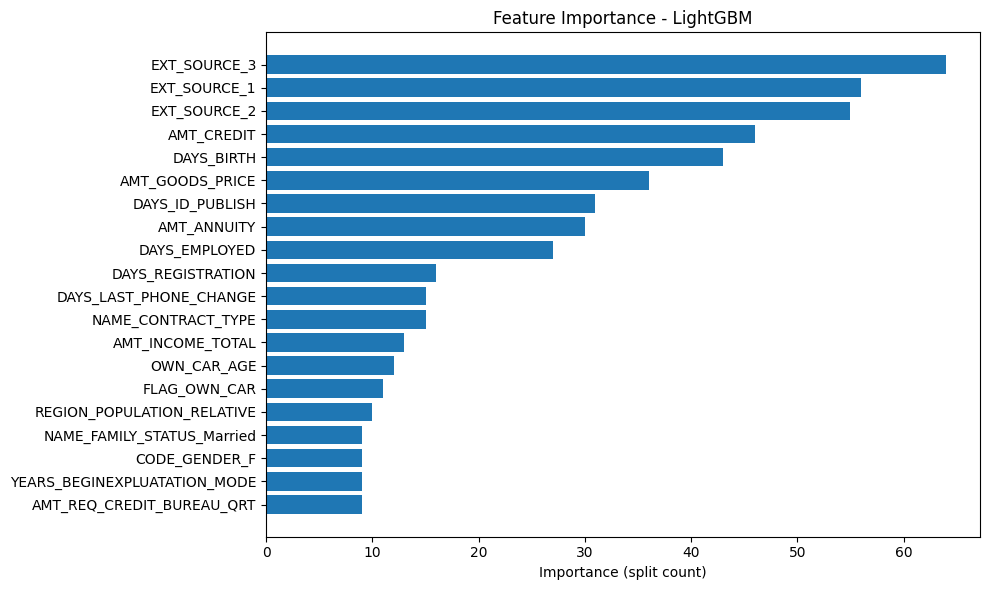

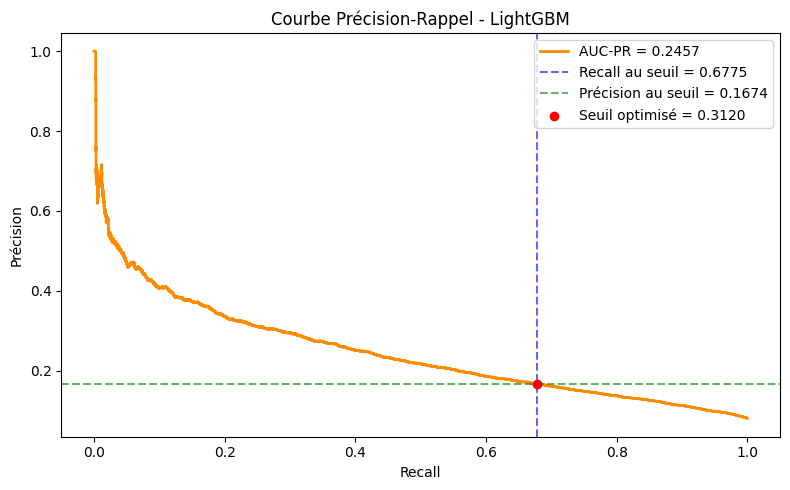

2026/02/20 21:08:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/20 21:08:04 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
Registered model 'LightGBM_Optuna_Optimized' already exists. Creating a new version of this model...
2026/02/20 21:08:19 WARNING mlflow.tracking._model_registry.fluent: Run with id 85b6cf76163e435bb8c4a1e82cd4d0aa has no artifacts at artifact path 'model', registering model based on models:/m-8e83f531986042218ad737f41fa1cbc8 instead
Created version '1' of model 'LightGBM_Optuna_Optimized'.


<ModelVersion: aliases=[], creation_timestamp=1771618099328, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1771618099328, metrics=None, model_id=None, name='LightGBM_Optuna_Optimized', params=None, run_id='85b6cf76163e435bb8c4a1e82cd4d0aa', run_link=None, source='models:/m-8e83f531986042218ad737f41fa1cbc8', status='READY', status_message=None, tags={}, user_id=None, version=1>

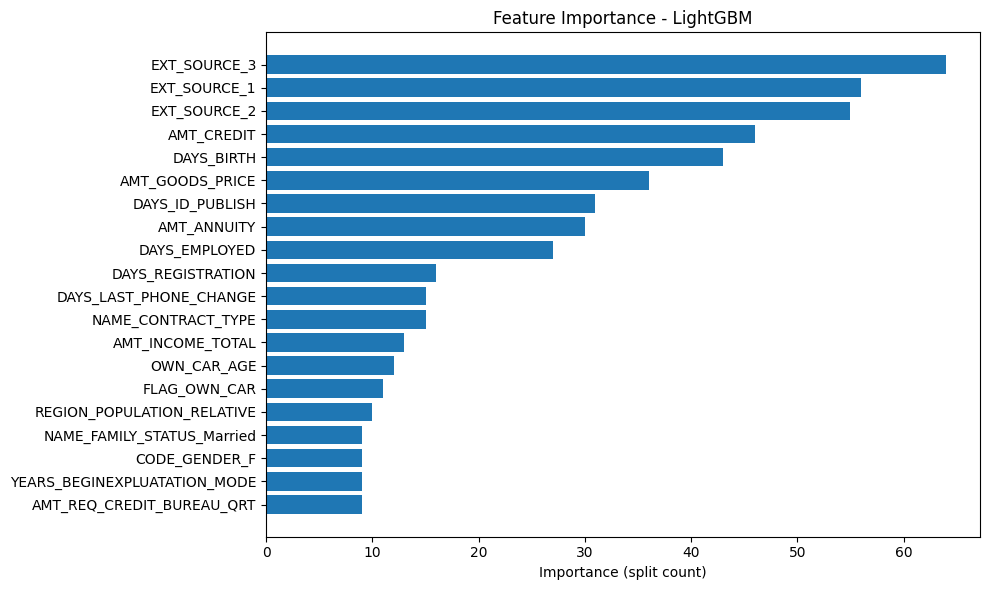

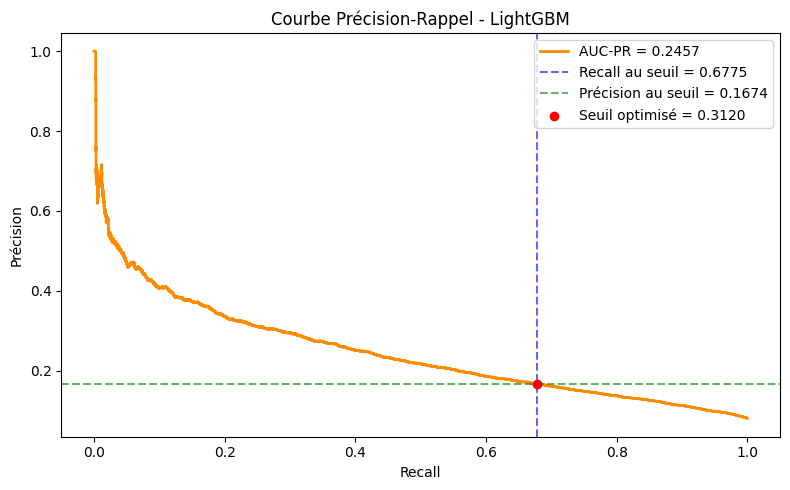

In [36]:
# Optuna + LightGBM + MLflow

def objective(trial):

    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "num_leaves": trial.suggest_int("num_leaves", 5, 10),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5, 10)
    }

    model = lgb.LGBMClassifier(**params, n_estimators=50)

    # Probabilités en CV
    y_proba = cross_val_predict(
        model, X_train, y_train,
        cv=skf,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    roc_auc = roc_auc_score(y_train, y_proba)

    #  Optimisation du seuil métier
    threshold = trial.suggest_float("threshold", 0.1, 0.9)
    y_pred = (y_proba > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()

    # Coût métier
    cost = fn * 10 + fp * 1

    # On veut maximiser AUC ET minimiser coût
    score = roc_auc - (cost / len(y_train))

    return score

# Optimisation
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Recherche du meilleur modele
best_params = study.best_params
best_threshold_lgb_opt = best_params.pop("threshold")

model_best = lgb.LGBMClassifier(**best_params)
model_best.fit(X_train, y_train)

y_val_proba = model_best.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba > best_threshold_lgb_opt).astype(int)

# Métriques métier sur le SET DE VALIDATION
roc_auc_val_lgb_opt  = roc_auc_score(y_val, y_val_proba)
tn_val_lgb_opt , fp_val_lgb_opt , fn_val_lgb_opt , tp_val_lgb_opt  = confusion_matrix(y_val, y_val_pred).ravel()
cost_val_lgb_opt  = fn_val_lgb_opt  * 10 + fp_val_lgb_opt  * 1
score_val_lgb_opt  = roc_auc_val_lgb_opt  - (cost_val_lgb_opt  / len(y_val))

# Précision / Recall au seuil optimisé
precision_lgb_opt = precision_score(y_val, y_val_pred)
recall_lgb_opt    = recall_score(y_val, y_val_pred)

# Courbe Précision-Rappel + AUC-PR
precisions, recalls, _ = precision_recall_curve(y_val, y_val_proba)
auc_pr_lgb_opt = auc(recalls, precisions)

print(f"  ROC-AUC_lgb_opt               : {roc_auc_val_lgb_opt :.4f}")
print(f"  AUC-PR_lgb_opt               : {auc_pr_lgb_opt:.4f}")
print(f"  Seuil optimisé_lgb_opt       : {best_threshold_lgb_opt:.4f}")
print(f"  Précision_lgb_opt             : {precision_lgb_opt:.4f}")
print(f"  Recall_lgb_opt                : {recall_lgb_opt:.4f}")
print(f"  Faux Négatifs (fn)_lgp_opt    : {fn_val_lgb_opt }  (coût x10 → {fn_val_lgb_opt  * 10})")
print(f"  Faux Positifs (fp)_lgp_opt     : {fp_val_lgb_opt }  (coût x1  → {fp_val_lgb_opt  * 1})")
print(f"  Coût métier total_lgp_opt      : {cost_val_lgb_opt }")
print(f"  Score Optuna (val)_lgp_opt     : {score_val_lgb_opt :.4f}")

# Feature Importance LightGBM
feature_importance = model_best.feature_importances_
feature_names = X_train.columns

# Tri par importance décroissante
sorted_idx = feature_importance.argsort()[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_names = feature_names[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
plt.xlabel("Importance (split count)")
plt.title("Feature Importance - LightGBM")
plt.tight_layout()
plt.show()

# Courbe Précision-Rappel
# -----------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2,
         label=f"AUC-PR = {auc_pr_lgb_opt:.4f}")
plt.axvline(x=recall_lgb_opt, color="blue", linestyle="--", alpha=0.6,
            label=f"Recall au seuil = {recall_lgb_opt:.4f}")
plt.axhline(y=precision_lgb_opt, color="green", linestyle="--", alpha=0.6,
            label=f"Précision au seuil = {precision_lgb_opt:.4f}")
plt.scatter([recall_lgb_opt], [precision_lgb_opt], color="red", zorder=5,
            label=f"Seuil optimisé = {best_threshold_lgb_opt:.4f}")
plt.xlabel("Recall")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel - LightGBM")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Log avec mlflow
with mlflow.start_run(run_name="LightGBM_Optuna_Optimized") as run:

    mlflow.log_params(best_params)
    mlflow.log_param("optimized_threshold", best_threshold_lgb_opt)

    mlflow.log_metric("roc_auc_lgb_opt ", roc_auc_val_lgb_opt )
    mlflow.log_metric("auc_pr_lgb_opt", auc_pr_lgb_opt)
    mlflow.log_metric("precision_lgb_opt", precision_lgb_opt)
    mlflow.log_metric("recall_lgb_opt", recall_lgb_opt)
    mlflow.log_metric("fn_val_lgb_opt ", fn_val_lgb_opt )
    mlflow.log_metric("fp_val_lgb_opt ", fp_val_lgb_opt )
    mlflow.log_metric("cost_val_lgb_opt ", cost_val_lgb_opt )
    mlflow.log_metric("score_lgb_opt ", score_val_lgb_opt )

    mlflow.lightgbm.log_model(model_best, "model")

    # Feature importance figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
    ax.set_xlabel("Importance (split count)")
    ax.set_title("Feature Importance - LightGBM")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")

    # Courbe PR figure
    fig_pr, ax2 = plt.subplots(figsize=(8, 5))
    ax2.plot(recalls, precisions, color="darkorange", lw=2,
             label=f"AUC-PR = {auc_pr_lgb_opt:.4f}")
    ax2.axvline(x=recall_lgb_opt, color="blue", linestyle="--", alpha=0.6,
                label=f"Recall au seuil = {recall_lgb_opt:.4f}")
    ax2.axhline(y=precision_lgb_opt, color="green", linestyle="--", alpha=0.6,
                label=f"Précision au seuil = {precision_lgb_opt:.4f}")
    ax2.scatter([recall_lgb_opt], [precision_lgb_opt], color="red", zorder=5,
                label=f"Seuil optimisé = {best_threshold_lgb_opt:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Précision")
    ax2.set_title("Courbe Précision-Rappel - LightGBM")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    mlflow.log_figure(fig_pr, "precision_recall_curve.png")

    # Récupération automatique du run_id
    run_id = run.info.run_id

# Register
mlflow.register_model(
    f"runs:/{run_id}/model",
    "LightGBM_Optuna_Optimized"
)


[I 2026-02-20 21:08:19,761] A new study created in memory with name: no-name-2134decd-9034-4e9e-b34c-736ac0c527f2
[I 2026-02-20 21:08:42,371] Trial 0 finished with value: 0.17544970274445537 and parameters: {'learning_rate': 0.16221449063520774, 'max_depth': 9, 'min_child_weight': 18, 'subsample': 0.6656595036416176, 'colsample_bytree': 0.7972878500875474, 'scale_pos_weight': 8.060571167785696, 'threshold': 0.33133971235413173}. Best is trial 0 with value: 0.17544970274445537.
[I 2026-02-20 21:09:08,050] Trial 1 finished with value: -0.0370612829380228 and parameters: {'learning_rate': 0.09863081564255984, 'max_depth': 8, 'min_child_weight': 18, 'subsample': 0.9798837014770416, 'colsample_bytree': 0.7082520072426904, 'scale_pos_weight': 9.058370248581824, 'threshold': 0.8304834411655831}. Best is trial 0 with value: 0.17544970274445537.
[I 2026-02-20 21:09:27,479] Trial 2 finished with value: 0.03564462390780998 and parameters: {'learning_rate': 0.1214649383812445, 'max_depth': 5, 'min

  ROC-AUC_xgb_opt               : 0.7578
  AUC-PR_xgb_opt               : 0.2449
  Seuil optimisé_xgb_opt       : 0.4410
  Précision_xgb_opt             : 0.1672
  Recall_xgb_opt                : 0.6783
  Faux Négatifs (fn)_xgb_opt    : 1597  (coût x10 → 15970)
  Faux Positifs (fp)_xgb_opt    : 16778  (coût x1  → 16778)
  Coût métier total_xgb_opt     : 32748
  Score Optuna (val)_xgb_opt    : 0.2253


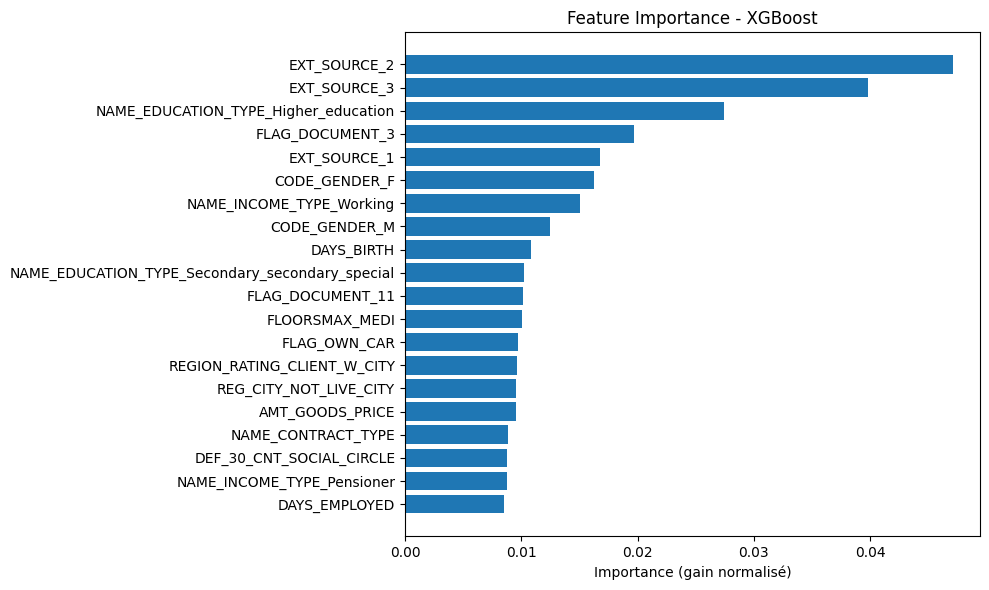

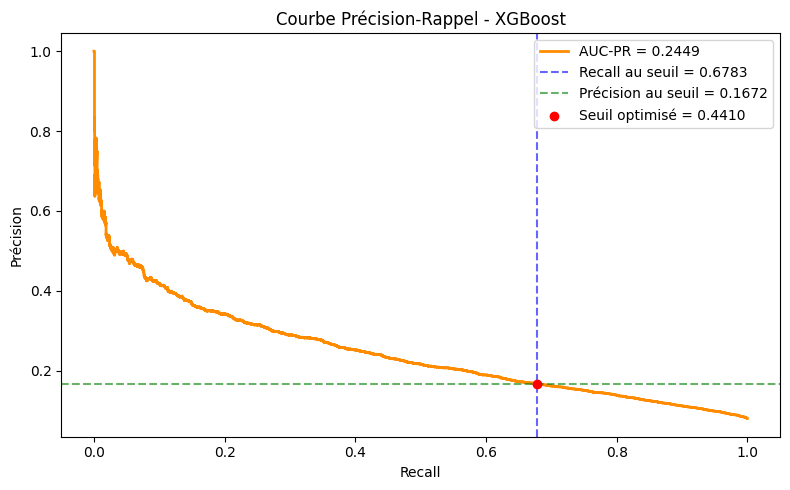

2026/02/20 21:16:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'XGBoost_Optuna_Optimized'.
2026/02/20 21:16:26 WARNING mlflow.tracking._model_registry.fluent: Run with id c0c92a72842445c7ac186a8769e68c6b has no artifacts at artifact path 'model', registering model based on models:/m-0ef321ea21754a9485dc3351ef6dbe68 instead
Created version '1' of model 'XGBoost_Optuna_Optimized'.


<ModelVersion: aliases=[], creation_timestamp=1771618586696, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1771618586696, metrics=None, model_id=None, name='XGBoost_Optuna_Optimized', params=None, run_id='c0c92a72842445c7ac186a8769e68c6b', run_link=None, source='models:/m-0ef321ea21754a9485dc3351ef6dbe68', status='READY', status_message=None, tags={}, user_id=None, version=1>

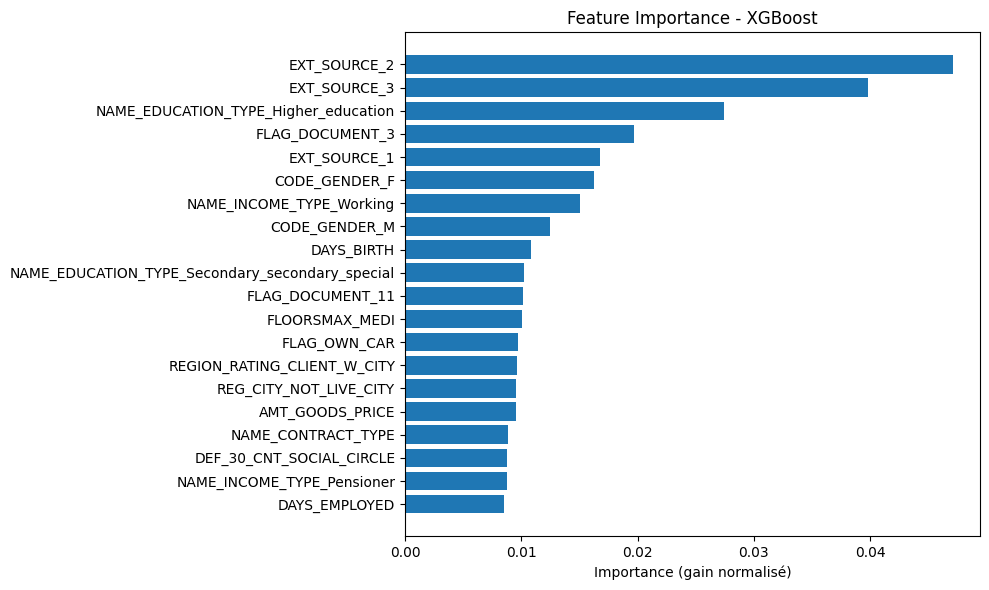

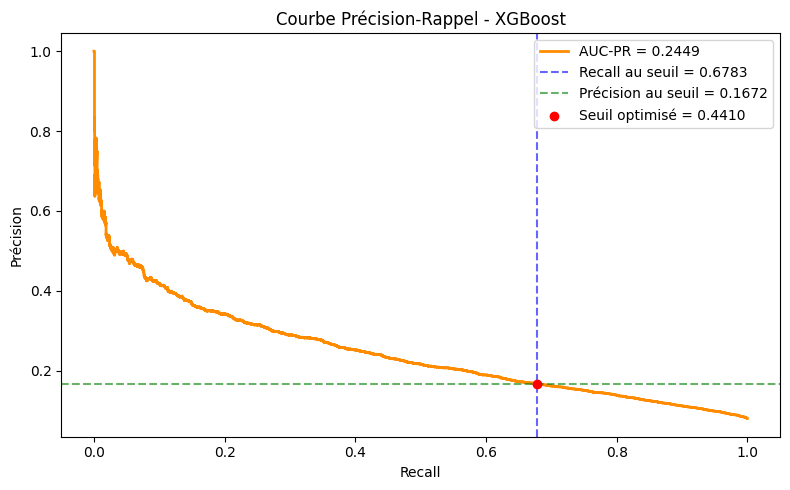

In [37]:
# Optuna + XGBoost + MLflow

def objective_xgb(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "booster": "gbtree",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5, 10),
        "n_estimators": 50,
        "use_label_encoder": False,
    }

    model = xgb.XGBClassifier(**params, verbosity=0)

    y_proba = cross_val_predict(
        model, X_train, y_train,
        cv=skf,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    roc_auc = roc_auc_score(y_train, y_proba)

    threshold = trial.suggest_float("threshold", 0.1, 0.9)
    y_pred = (y_proba > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    cost = fn * 10 + fp * 1
    score = roc_auc - (cost / len(y_train))

    return score


study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=20)

best_params_xgb = study_xgb.best_params
best_threshold_xgb = best_params_xgb.pop("threshold")

model_best_xgb = xgb.XGBClassifier(**best_params_xgb, verbosity=0)
model_best_xgb.fit(X_train, y_train)

y_val_proba_xgb = model_best_xgb.predict_proba(X_val)[:, 1]
y_val_pred_xgb = (y_val_proba_xgb > best_threshold_xgb).astype(int)

# Métriques métier sur le SET DE VALIDATION
roc_auc_xgb_opt = roc_auc_score(y_val, y_val_proba_xgb)

tn_val_xgb_opt, fp_val_xgb_opt, fn_val_xgb_opt, tp_val_xgb_opt = confusion_matrix(y_val, y_val_pred_xgb).ravel()
cost_val_xgb_opt = fn_val_xgb_opt * 10 + fp_val_xgb_opt * 1
score_val_xgb_opt = roc_auc_xgb_opt - (cost_val_xgb_opt / len(y_val))

# Précision / Recall au seuil optimisé
precision_xgb_opt = precision_score(y_val, y_val_pred_xgb)
recall_xgb_opt    = recall_score(y_val, y_val_pred_xgb)

# Courbe Précision-Rappel + AUC-PR
precisions, recalls, _ = precision_recall_curve(y_val, y_val_proba_xgb)
auc_pr_xgb_opt = auc(recalls, precisions)

print(f"  ROC-AUC_xgb_opt               : {roc_auc_xgb_opt :.4f}")
print(f"  AUC-PR_xgb_opt               : {auc_pr_xgb_opt:.4f}")
print(f"  Seuil optimisé_xgb_opt       : {best_threshold_xgb:.4f}")
print(f"  Précision_xgb_opt             : {precision_xgb_opt:.4f}")
print(f"  Recall_xgb_opt                : {recall_xgb_opt:.4f}")
print(f"  Faux Négatifs (fn)_xgb_opt    : {fn_val_xgb_opt}  (coût x10 → {fn_val_xgb_opt * 10})")
print(f"  Faux Positifs (fp)_xgb_opt    : {fp_val_xgb_opt}  (coût x1  → {fp_val_xgb_opt * 1})")
print(f"  Coût métier total_xgb_opt     : {cost_val_xgb_opt}")
print(f"  Score Optuna (val)_xgb_opt    : {score_val_xgb_opt:.4f}")

# Feature Importance XGBoost
feature_importance = model_best_xgb.feature_importances_
feature_names = X_train.columns

# Tri par importance décroissante
sorted_idx = feature_importance.argsort()[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_names = feature_names[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
plt.xlabel("Importance (gain normalisé)")
plt.title("Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

# Courbe Précision-Rappel

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2,
         label=f"AUC-PR = {auc_pr_xgb_opt:.4f}")
plt.axvline(x=recall_xgb_opt, color="blue", linestyle="--", alpha=0.6,
            label=f"Recall au seuil = {recall_xgb_opt:.4f}")
plt.axhline(y=precision_xgb_opt, color="green", linestyle="--", alpha=0.6,
            label=f"Précision au seuil = {precision_xgb_opt:.4f}")
plt.scatter([recall_xgb_opt], [precision_xgb_opt], color="red", zorder=5,
            label=f"Seuil optimisé = {best_threshold_xgb:.4f}")
plt.xlabel("Recall")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel - XGBoost")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# mlflow
with mlflow.start_run(run_name="XGBoost_Optuna_Optimized") as run:
    mlflow.log_params(best_params_xgb)
    mlflow.log_param("optimized_threshold_xgb", best_threshold_xgb)

    mlflow.log_metric("roc_auc_xgb_opt", roc_auc_xgb_opt)
    mlflow.log_metric("auc_pr_xgb_opt", auc_pr_xgb_opt)
    mlflow.log_metric("precision_xgb_opt", precision_xgb_opt)
    mlflow.log_metric("recall_xgb_opt", recall_xgb_opt)
    mlflow.log_metric("fn_xgb_opt", fn_val_xgb_opt)
    mlflow.log_metric("fp_xgb_opt", fp_val_xgb_opt)
    mlflow.log_metric("cost_xgb_opt", cost_val_xgb_opt)
    mlflow.log_metric("score_xgb_opt", score_val_xgb_opt)

    mlflow.xgboost.log_model(model_best_xgb, "model")

    # Feature importance figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
    ax.set_xlabel("Importance (gain normalisé)")
    ax.set_title("Feature Importance - XGBoost")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")

    # Courbe PR figure
    fig_pr, ax2 = plt.subplots(figsize=(8, 5))
    ax2.plot(recalls, precisions, color="darkorange", lw=2,
             label=f"AUC-PR = {auc_pr_xgb_opt:.4f}")
    ax2.axvline(x=recall_xgb_opt, color="blue", linestyle="--", alpha=0.6,
                label=f"Recall au seuil = {recall_xgb_opt:.4f}")
    ax2.axhline(y=precision_xgb_opt, color="green", linestyle="--", alpha=0.6,
                label=f"Précision au seuil = {precision_xgb_opt:.4f}")
    ax2.scatter([recall_xgb_opt], [precision_xgb_opt], color="red", zorder=5,
                label=f"Seuil optimisé = {best_threshold_xgb:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Précision")
    ax2.set_title("Courbe Précision-Rappel - XGBoost")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    mlflow.log_figure(fig_pr, "precision_recall_curve.png")

    # Récupération automatique du run_id
    run_id = run.info.run_id

# Register
mlflow.register_model(
    f"runs:/{run_id}/model",
    "XGBoost_Optuna_Optimized"
)


[I 2026-02-20 21:16:27,158] A new study created in memory with name: no-name-fad43ea1-1537-4bbe-9278-3a1d8d828534
[I 2026-02-20 21:16:47,750] Trial 0 finished with value: -0.014099786920399704 and parameters: {'learning_rate': 0.1319955753669225, 'depth': 8, 'min_data_in_leaf': 9, 'subsample': 0.635202958325375, 'colsample_bylevel': 0.9672789567412773, 'auto_class_weights': 'SqrtBalanced', 'threshold': 0.5975609837125984}. Best is trial 0 with value: -0.014099786920399704.
[I 2026-02-20 21:16:59,827] Trial 1 finished with value: 0.1285306353373945 and parameters: {'learning_rate': 0.1608565462478727, 'depth': 5, 'min_data_in_leaf': 17, 'subsample': 0.641042953855571, 'colsample_bylevel': 0.7079142584722601, 'auto_class_weights': 'SqrtBalanced', 'threshold': 0.39237115339124884}. Best is trial 1 with value: 0.1285306353373945.
[I 2026-02-20 21:17:11,926] Trial 2 finished with value: 0.19073357216763565 and parameters: {'learning_rate': 0.1401350136813949, 'depth': 4, 'min_data_in_leaf':

  ROC-AUC_cat_opt               : 0.7595
  AUC-PR_cat_opt               : 0.2520
  Seuil optimisé_cat_opt        : 0.5355
  Précision_cat_opt             : 0.1859
  Recall_cat_opt               : 0.6089
  Faux Négatifs (fn)_cat_opt    : 1942  (coût x10 → 19420)
  Faux Positifs (fp)_cat_opt    : 13239  (coût x1  → 13239)
  Coût métier total_cat_opt     : 32659
  Score Optuna (val)_cat_opt    : 0.2285


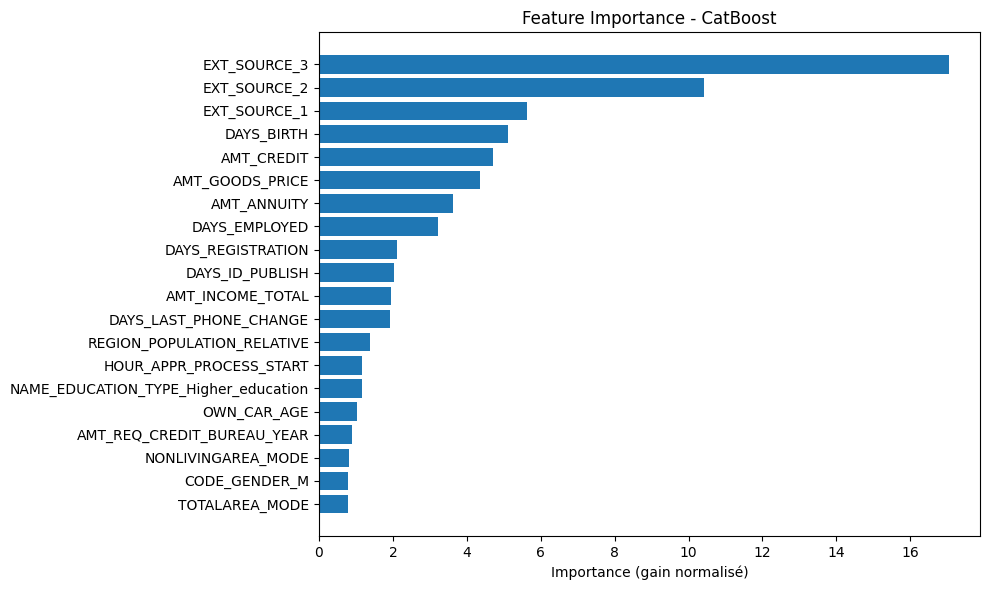

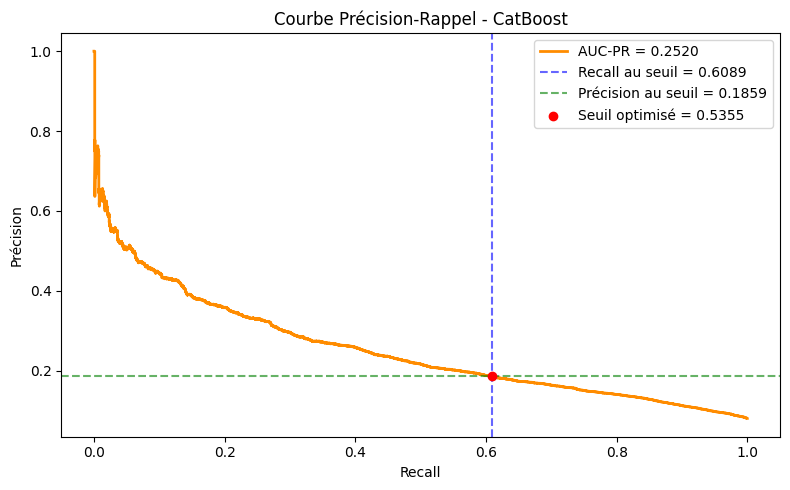

2026/02/20 21:22:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'CatBoost_Optuna_Optimized'.
2026/02/20 21:22:44 WARNING mlflow.tracking._model_registry.fluent: Run with id 0ef0b1bc3e4f4897bdfc00e0ba3e6e96 has no artifacts at artifact path 'model', registering model based on models:/m-40d7eec5749a44cb9f3195677d637ce5 instead
Created version '1' of model 'CatBoost_Optuna_Optimized'.


<ModelVersion: aliases=[], creation_timestamp=1771618964958, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1771618964958, metrics=None, model_id=None, name='CatBoost_Optuna_Optimized', params=None, run_id='0ef0b1bc3e4f4897bdfc00e0ba3e6e96', run_link=None, source='models:/m-40d7eec5749a44cb9f3195677d637ce5', status='READY', status_message=None, tags={}, user_id=None, version=1>

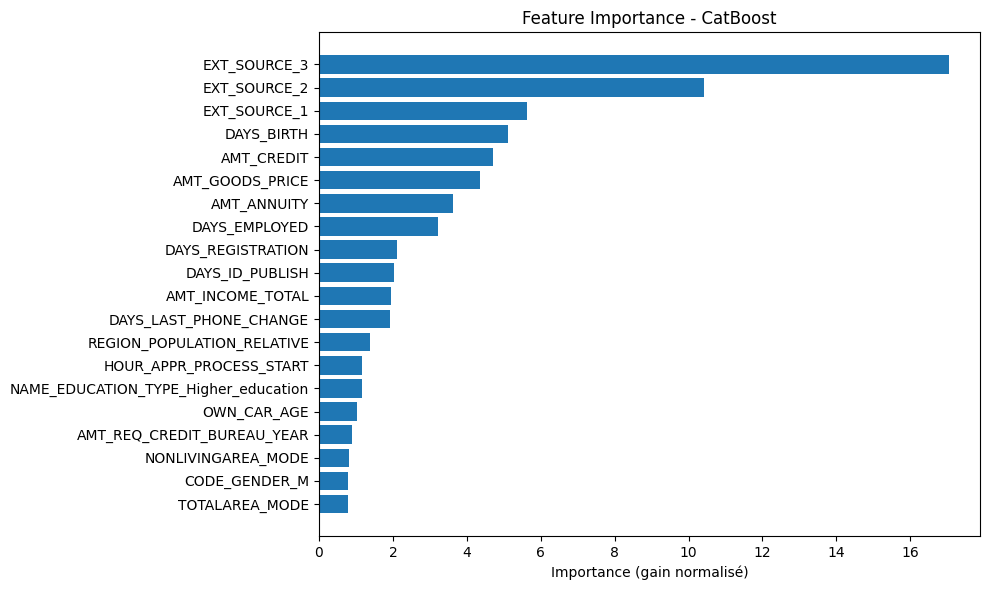

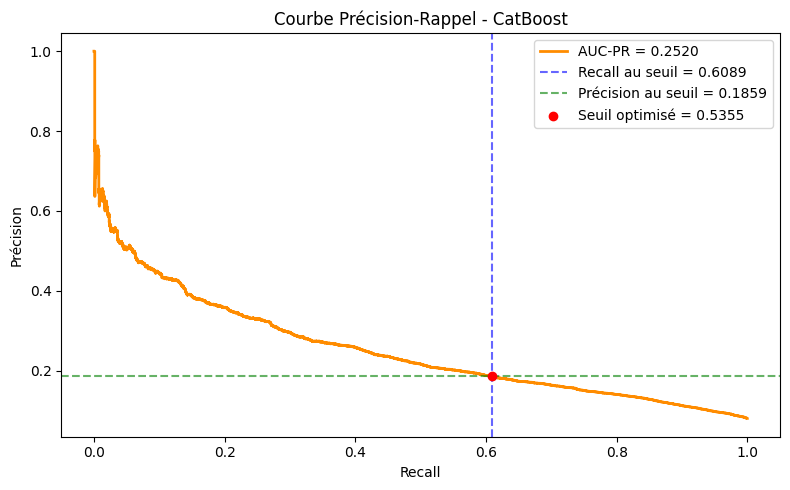

In [38]:
# Optuna + CatBoost + MLflow

def objective_cat(trial):

    params = {
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "depth": trial.suggest_int("depth", 3, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", ["Balanced", "SqrtBalanced"]),
        "iterations": 50,
        "verbose": 0,
    }

    model = CatBoostClassifier(**params)

    y_proba = cross_val_predict(
        model, X_train, y_train,
        cv=skf,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    roc_auc = roc_auc_score(y_train, y_proba)

    threshold = trial.suggest_float("threshold", 0.1, 0.9)
    y_pred = (y_proba > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    cost = fn * 10 + fp * 1
    score = roc_auc - (cost / len(y_train))

    return score


study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=20)

best_params_cat = study_cat.best_params
best_threshold_cat = best_params_cat.pop("threshold")

model_best_cat = CatBoostClassifier(**best_params_cat, verbose=0)
model_best_cat.fit(X_train, y_train)

y_val_proba_cat = model_best_cat.predict_proba(X_val)[:, 1]
y_val_pred_cat = (y_val_proba_cat > best_threshold_cat).astype(int)

# Métriques métier sur le SET DE VALIDATION
roc_auc_cat_opt = roc_auc_score(y_val, y_val_proba_cat)

tn_val_cat_opt , fp_val_cat_opt, fn_val_cat_opt , tp_val_cat_opt  = confusion_matrix(y_val, y_val_pred_cat).ravel()
cost_val_cat_opt  = fn_val_cat_opt  * 10 + fp_val_cat_opt  * 1
score_val_cat_opt  = roc_auc_cat_opt  - (cost_val_cat_opt  / len(y_val))

# Précision / Recall au seuil optimisé
precision_cat_opt = precision_score(y_val, y_val_pred_cat)
recall_cat_opt    = recall_score(y_val, y_val_pred_cat)

# Courbe Précision-Rappel + AUC-PR
precisions, recalls, _ = precision_recall_curve(y_val, y_val_proba_cat)
auc_pr_cat_opt = auc(recalls, precisions)

print(f"  ROC-AUC_cat_opt               : {roc_auc_cat_opt:.4f}")
print(f"  AUC-PR_cat_opt               : {auc_pr_cat_opt:.4f}")
print(f"  Seuil optimisé_cat_opt        : {best_threshold_cat:.4f}")
print(f"  Précision_cat_opt             : {precision_cat_opt:.4f}")
print(f"  Recall_cat_opt               : {recall_cat_opt:.4f}")
print(f"  Faux Négatifs (fn)_cat_opt    : {fn_val_cat_opt}  (coût x10 → {fn_val_cat_opt * 10})")
print(f"  Faux Positifs (fp)_cat_opt    : {fp_val_cat_opt}  (coût x1  → {fp_val_cat_opt * 1})")
print(f"  Coût métier total_cat_opt     : {cost_val_cat_opt}")
print(f"  Score Optuna (val)_cat_opt    : {score_val_cat_opt:.4f}")


# Feature Importance CatBoost (méthode native)
feature_importance = model_best_cat.get_feature_importance()
feature_names = X_train.columns
sorted_idx = feature_importance.argsort()[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_names = feature_names[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
plt.xlabel("Importance (gain normalisé)")
plt.title("Feature Importance - CatBoost")
plt.tight_layout()
plt.show()

# Courbe Précision-Rappel

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2,
         label=f"AUC-PR = {auc_pr_cat_opt:.4f}")
plt.axvline(x=recall_cat_opt, color="blue", linestyle="--", alpha=0.6,
            label=f"Recall au seuil = {recall_cat_opt:.4f}")
plt.axhline(y=precision_cat_opt, color="green", linestyle="--", alpha=0.6,
            label=f"Précision au seuil = {precision_cat_opt:.4f}")
plt.scatter([recall_cat_opt], [precision_cat_opt], color="red", zorder=5,
            label=f"Seuil optimisé = {best_threshold_cat:.4f}")
plt.xlabel("Recall")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel - CatBoost")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

with mlflow.start_run(run_name="CatBoost_Optuna_Optimized") as run:

    mlflow.log_params(best_params_cat)
    mlflow.log_param("optimized_threshold", best_threshold_cat)

    mlflow.log_metric("roc_auc_cat_opt", roc_auc_cat_opt)
    mlflow.log_metric("auc_pr_cat_opt", auc_pr_cat_opt)
    mlflow.log_metric("precision_cat_opt", precision_cat_opt)
    mlflow.log_metric("recall_cat_opt", recall_cat_opt)
    mlflow.log_metric("fn_val_cat_opt", fn_val_cat_opt)
    mlflow.log_metric("fp_val_cat_opt", fp_val_cat_opt)
    mlflow.log_metric("cost_val_cat_opt", cost_val_cat_opt)
    mlflow.log_metric("score_val_cat_opt", score_val_cat_opt)

    mlflow.catboost.log_model(model_best_cat, "model")
    
    # Feature importance figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
    ax.set_xlabel("Importance (gain normalisé)")
    ax.set_title("Feature Importance - CatBoost")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")

    # Courbe PR figure
    fig_pr, ax2 = plt.subplots(figsize=(8, 5))
    ax2.plot(recalls, precisions, color="darkorange", lw=2,
             label=f"AUC-PR = {auc_pr_cat_opt:.4f}")
    ax2.axvline(x=recall_cat_opt, color="blue", linestyle="--", alpha=0.6,
                label=f"Recall au seuil = {recall_cat_opt:.4f}")
    ax2.axhline(y=precision_cat_opt, color="green", linestyle="--", alpha=0.6,
                label=f"Précision au seuil = {precision_cat_opt:.4f}")
    ax2.scatter([recall_cat_opt], [precision_cat_opt], color="red", zorder=5,
                label=f"Seuil optimisé = {best_threshold_cat:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Précision")
    ax2.set_title("Courbe Précision-Rappel - CatBoost")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    mlflow.log_figure(fig_pr, "precision_recall_curve.png")

    # Récupération automatique du run_id
    run_id = run.info.run_id

# Register
mlflow.register_model(
    f"runs:/{run_id}/model",
    "CatBoost_Optuna_Optimized"
)

In [43]:
# Résumé comparatif des 3 modèles Optimisés
summary_data = {
    "Modèle": ["LightGBM_opt", "XGBoost_opt", "CatBoost_opt"],
    "Seuil optimisé": [best_threshold_lgb_opt, best_threshold_xgb, best_threshold_cat],
    "ROC-AUC": [roc_auc_val_lgb_opt, roc_auc_xgb_opt, roc_auc_cat_opt],
    "AUC-PR": [auc_pr_lgb_opt,auc_pr_xgb_opt,auc_pr_cat_opt],
    "Précision": [precision_lgb_opt,precision_xgb_opt,precision_cat_opt],
    "Recall": [recall_lgb_opt,recall_xgb_opt,recall_cat_opt],
    "FN": [fn_val_lgb_opt, fn_val_xgb_opt, fn_val_cat_opt],
    "Coût FN": [fn_val_lgb_opt * 10, fn_val_xgb_opt * 10, fn_val_cat_opt * 10],
    "FP": [fp_val_lgb_opt, fp_val_xgb_opt, fp_val_cat_opt],
    "Coût FP": [fp_val_lgb_opt * 1, fp_val_xgb_opt * 1, fp_val_cat_opt * 1],
    "Coût total": [cost_val_lgb_opt, cost_val_xgb_opt, cost_val_cat_opt],
    "Score": [score_val_lgb_opt, score_val_xgb_opt, score_val_cat_opt],
}

df_summary = pd.DataFrame(summary_data).set_index("Modèle")

# Arrondi des colonnes float
float_cols = ["Seuil optimisé", "ROC-AUC", "AUC-PR", "Précision", "Recall", "Score"]
df_summary[float_cols] = df_summary[float_cols].round(4)

# Affichage
print("Comparaison des modèles - Set de Validation")
print(df_summary.to_string())

Comparaison des modèles - Set de Validation
              Seuil optimisé  ROC-AUC  AUC-PR  Précision  Recall    FN  Coût FN     FP  Coût FP  Coût total   Score
Modèle                                                                                                             
LightGBM_opt          0.3120   0.7570  0.2457     0.1674  0.6775  1601    16010  16728    16728       32738  0.2247
XGBoost_opt           0.4410   0.7578  0.2449     0.1672  0.6783  1597    15970  16778    16778       32748  0.2253
CatBoost_opt          0.5355   0.7595  0.2520     0.1859  0.6089  1942    19420  13239    13239       32659  0.2285


In [ ]:
# résultats visuels:
## CatBoost:
## Meilleur ROC-AUC
## Meilleur AUC-PR
## Meilleur Score
## Coût total (le plus important) plus faible: faible coût FP compense hausse du coût FN
## => CatBoost minimise le risque financier

In [44]:
#  Log MLflow — un run par modèle + un run résumé "Comparaison_3_Modeles" (onglet Compare de mlflow)
with mlflow.start_run(run_name="Comparaison_3_Modeles"):

    for _, row in df_summary.reset_index().iterrows():
        modele = row["Modèle"]
        with mlflow.start_run(run_name=f"Comparaison_{modele}", nested=True):
            mlflow.log_metric("seuil_optimise", row["Seuil optimisé"])
            mlflow.log_metric("roc_auc", row["ROC-AUC"])
            mlflow.log_metric("auc_pr", row["AUC-PR"])
            mlflow.log_metric("Précision", row["Précision"])
            mlflow.log_metric("Recall", row["Recall"])
            mlflow.log_metric("fn", row["FN"])
            mlflow.log_metric("cout_fn", row["Coût FN"])
            mlflow.log_metric("fp", row["FP"])
            mlflow.log_metric("cout_fp", row["Coût FP"])
            mlflow.log_metric("cout_total", row["Coût total"])
            mlflow.log_metric("score", row["Score"])

    # Log du tableau complet en CSV 
    csv_path = "comparaison_modeles.csv"
    df_summary.to_csv(csv_path)
    mlflow.log_artifact(csv_path)

In [48]:
# SHAP sur le meilleur modèle : CatBoost

In [49]:
# Explainer SHAP pour CatBoost
explainer = shap.TreeExplainer(model_best_cat)
shap_values = explainer(X_val)

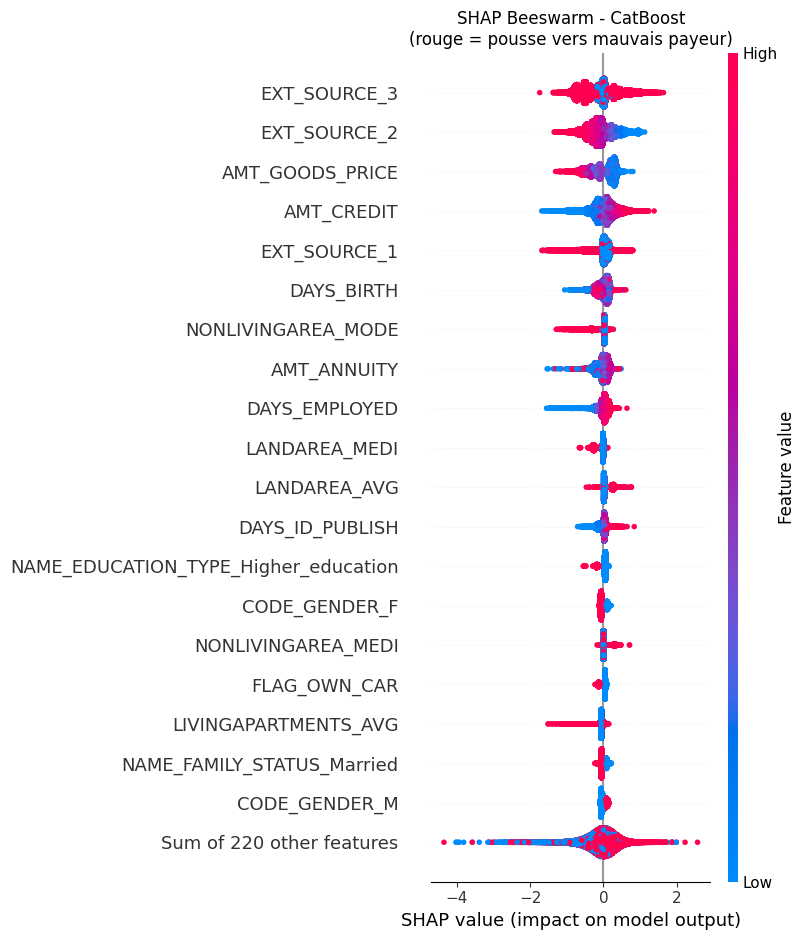

In [50]:
# BEESWARM — influence globale de chaque feature
# quelles features pour "mauvais payeur" (valeur SHAP positive = risque +)

plt.figure()
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Beeswarm - CatBoost\n(rouge = pousse vers mauvais payeur)")
plt.tight_layout()
plt.show()


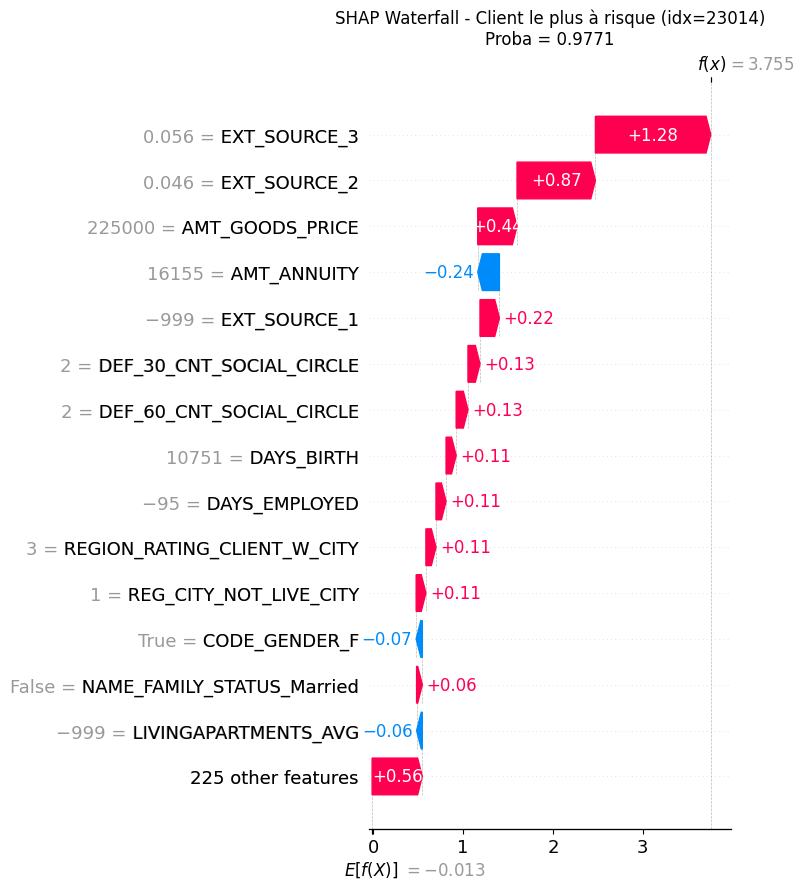

In [51]:
# WATERFALL — explication d'un individu précis
# Exemple : le client avec la proba la plus élevée (le plus à risque d'être mauvais payeur)

idx_most_risky = y_val_proba_cat.argmax()

plt.figure()
shap.plots.waterfall(shap_values[idx_most_risky], max_display=15, show=False)
plt.title(f"SHAP Waterfall - Client le plus à risque (idx={idx_most_risky})\nProba = {y_val_proba_cat[idx_most_risky]:.4f}")
plt.tight_layout()
plt.show()

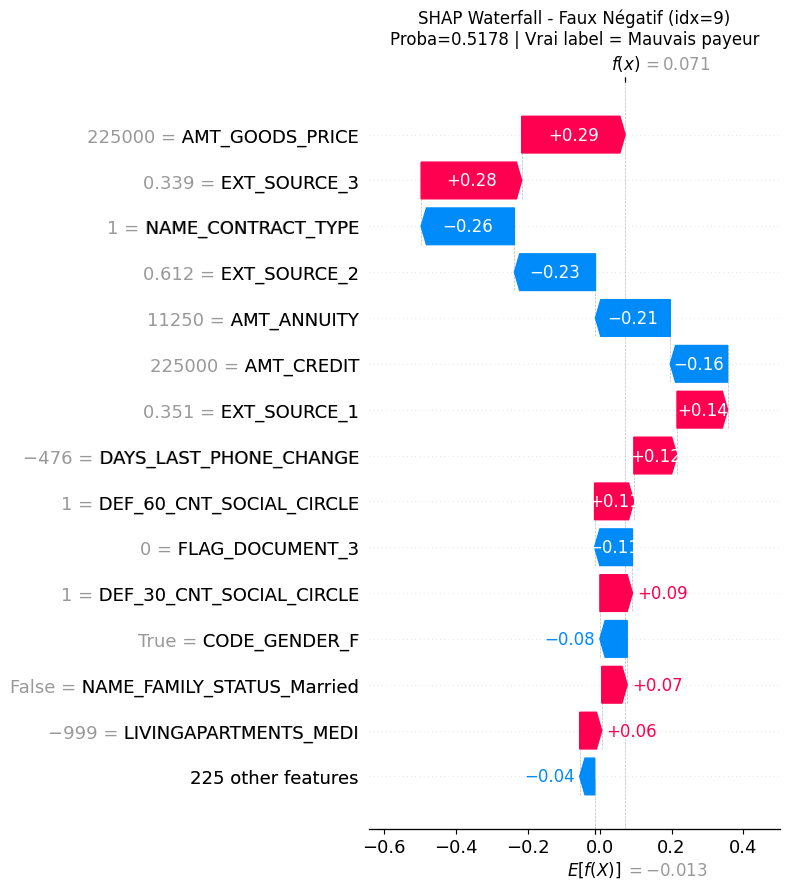

In [52]:
# Waterfall sur un faux négatif (mauvais payeur non détecté: ce qui est le plus cher)

fn_indices = np.where((y_val == 1) & (y_val_pred_cat == 0))[0]
if len(fn_indices) > 0:
    idx_fn = fn_indices[0]
    plt.figure()
    shap.plots.waterfall(shap_values[idx_fn], max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Faux Négatif (idx={idx_fn})\nProba={y_val_proba_cat[idx_fn]:.4f} | Vrai label = Mauvais payeur")
    plt.tight_layout()
    plt.show()


In [53]:
# Log MLflow
with mlflow.start_run(run_name="CatBoost_SHAP_Analysis"):

    # Beeswarm
    fig_bee, _ = plt.subplots()
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.title("SHAP Beeswarm - CatBoost")
    plt.tight_layout()
    mlflow.log_figure(fig_bee, "shap_beeswarm.png")

    # Waterfall client le plus risqué
    fig_wf, _ = plt.subplots()
    shap.plots.waterfall(shap_values[idx_most_risky], max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Client le plus à risque")
    plt.tight_layout()
    mlflow.log_figure(fig_wf, "shap_waterfall_most_risky.png")

    # Waterfall faux négatif
    if len(fn_indices) > 0:
        fig_fn, _ = plt.subplots()
        shap.plots.waterfall(shap_values[idx_fn], max_display=15, show=False)
        plt.title(f"SHAP Waterfall - Faux Négatif")
        plt.tight_layout()
        mlflow.log_figure(fig_fn, "shap_waterfall_false_negative.png")